# Lab 06 – Homework: Cat-versus-Dog CNN

- Name: ____________________
- Student ID: ______________

## Goal

Build a binary image classifier that distinguishes cats from dogs. The
original subject dataset contains 25,000 images. This notebook keeps the
image files on disk, uses a stratified train/validation/test split, and
applies transfer learning with MobileNetV2.

Set `MAX_IMAGES_PER_CLASS = None` in the configuration cell to use every
readable image. A smaller value is useful for a CPU smoke run. The
precision target is selected on the validation set, then reported once on
the test set so the test labels do not tune the threshold.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path
from zipfile import ZipFile

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
HEAD_EPOCHS = 4
FINE_TUNE_EPOCHS = 2
MAX_IMAGES_PER_CLASS = 2_000  # Use None for the full available dataset.
TARGET_PRECISION = 0.90

DATASET_URL = "https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip"
DATASET_ENV = "CPE342_CATS_DOGS_DIR"
DATA_DIR = Path(os.environ.get(DATASET_ENV, "data"))
ARCHIVE_PATH = DATA_DIR / "Cat_Dog_data.zip"
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
keras.utils.set_random_seed(RANDOM_STATE)

print(f"Keras {keras.__version__}; backend: {keras.config.backend()}")
print(f"TensorFlow {tf.__version__}")
print(f"Dataset location: {DATA_DIR.resolve()}")
print(f"Images per class: {MAX_IMAGES_PER_CLASS or 'all'}")


Keras 3.15.1; backend: tensorflow
TensorFlow 2.21.0
Dataset location: /Users/beam/Workspace/Course/my-cpe-lab/Y3/cpe342/lab06/data
Images per class: 2000


## 1. Acquire and validate the image paths

Do not commit the archive or extracted images to the repository. The cell
downloads the subject-provided archive only when no `cat` and `dog`
directories are found. You can point `CPE342_CATS_DOGS_DIR` at an
existing extracted dataset to avoid downloading it again.


In [2]:
def safe_extract(archive_path, destination):
    destination = destination.resolve()
    with ZipFile(archive_path) as archive:
        for member in archive.infolist():
            member_path = (destination / member.filename).resolve()
            if destination not in member_path.parents and member_path != destination:
                raise ValueError(f"Unsafe archive member: {member.filename}")
        archive.extractall(destination)


def locate_class_directories(root):
    class_dirs = {"cat": [], "dog": []}
    for path in root.rglob("*"):
        if path.is_dir() and path.name.lower() in class_dirs:
            class_dirs[path.name.lower()].append(path)
    return {
        name: sorted(paths)
        for name, paths in class_dirs.items()
        if paths
    }


class_dirs = locate_class_directories(DATA_DIR)
if set(class_dirs) != {"cat", "dog"}:
    if not ARCHIVE_PATH.exists():
        print("Downloading the subject archive; this can take several minutes...")
        downloaded_archive = keras.utils.get_file(
            fname=ARCHIVE_PATH.name,
            origin=DATASET_URL,
            cache_dir=str(DATA_DIR.parent),
            cache_subdir=DATA_DIR.name,
        )
        ARCHIVE_PATH = Path(downloaded_archive)
    print("Extracting the archive...")
    safe_extract(ARCHIVE_PATH, DATA_DIR)
    class_dirs = locate_class_directories(DATA_DIR)

if set(class_dirs) != {"cat", "dog"}:
    raise FileNotFoundError(
        "Expected directories named cat and dog. "
        f"Set {DATASET_ENV} to the extracted dataset root."
    )

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def image_paths(directory):
    return sorted(
        path for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


all_paths_by_class = {
    name: sorted(
        path
        for directory in class_dirs[name]
        for path in image_paths(directory)
    )
    for name in ("cat", "dog")
}
for name, paths in all_paths_by_class.items():
    if not paths:
        raise ValueError(f"No image files found for class {name!r}")
    print(f"{name.title()}: {len(paths):,} image files")


Cat: 25,000 image files
Dog: 25,000 image files


In [3]:
def readable_image(path):
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except (OSError, ValueError):
        return False


valid_paths_by_class = {}
for name, paths in all_paths_by_class.items():
    valid_paths = [path for path in paths if readable_image(path)]
    valid_paths_by_class[name] = valid_paths
    print(f"{name.title()}: {len(valid_paths):,} readable images")

if any(len(paths) == 0 for paths in valid_paths_by_class.values()):
    raise ValueError("At least one class has no readable images")

rng = np.random.default_rng(RANDOM_STATE)
selected_paths = []
selected_labels = []
for label, name in enumerate(("cat", "dog")):
    paths = valid_paths_by_class[name]
    if MAX_IMAGES_PER_CLASS is not None:
        if MAX_IMAGES_PER_CLASS < 2:
            raise ValueError("MAX_IMAGES_PER_CLASS must be at least 2 or None")
        n_selected = min(MAX_IMAGES_PER_CLASS, len(paths))
        selected = rng.choice(np.asarray(paths, dtype=object), n_selected, replace=False)
        paths = sorted(Path(path) for path in selected)
    selected_paths.extend(paths)
    selected_labels.extend([label] * len(paths))

selected_paths = np.asarray(selected_paths, dtype=object)
selected_labels = np.asarray(selected_labels, dtype=np.int32)
assert len(selected_paths) == len(selected_labels)
assert set(selected_labels) == {0, 1}
assert len(selected_paths) == sum(selected_labels == 0) + sum(selected_labels == 1)
print(f"Selected images: {len(selected_paths):,}")


Cat: 12,500 readable images


Dog: 12,500 readable images
Selected images: 4,000


## 2. Create a stratified split

Use 80% for training, 10% for validation, and 10% for testing. No path may
appear in more than one split. Labels use `0 = cat` and `1 = dog`.


In [4]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    selected_paths,
    selected_labels,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=selected_labels,
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=1 / 9,
    random_state=RANDOM_STATE,
    stratify=train_val_labels,
)

def path_set(paths):
    return {str(path) for path in paths}


assert path_set(train_paths).isdisjoint(path_set(val_paths))
assert path_set(train_paths).isdisjoint(path_set(test_paths))
assert path_set(val_paths).isdisjoint(path_set(test_paths))
assert set(np.unique(train_labels)) == {0, 1}
assert set(np.unique(val_labels)) == {0, 1}
assert set(np.unique(test_labels)) == {0, 1}

split_summary = pd.DataFrame(
    {
        "train": pd.Series(train_labels).value_counts().sort_index(),
        "validation": pd.Series(val_labels).value_counts().sort_index(),
        "test": pd.Series(test_labels).value_counts().sort_index(),
    },
    index=[0, 1],
)
split_summary.index = ["cat", "dog"]
display(split_summary)
print(
    f"Train: {len(train_paths):,}; validation: {len(val_paths):,}; "
    f"test: {len(test_paths):,}"
)


,train,validation,test
cat,1600,200,200
dog,1600,200,200


Train: 3,200; validation: 400; test: 400


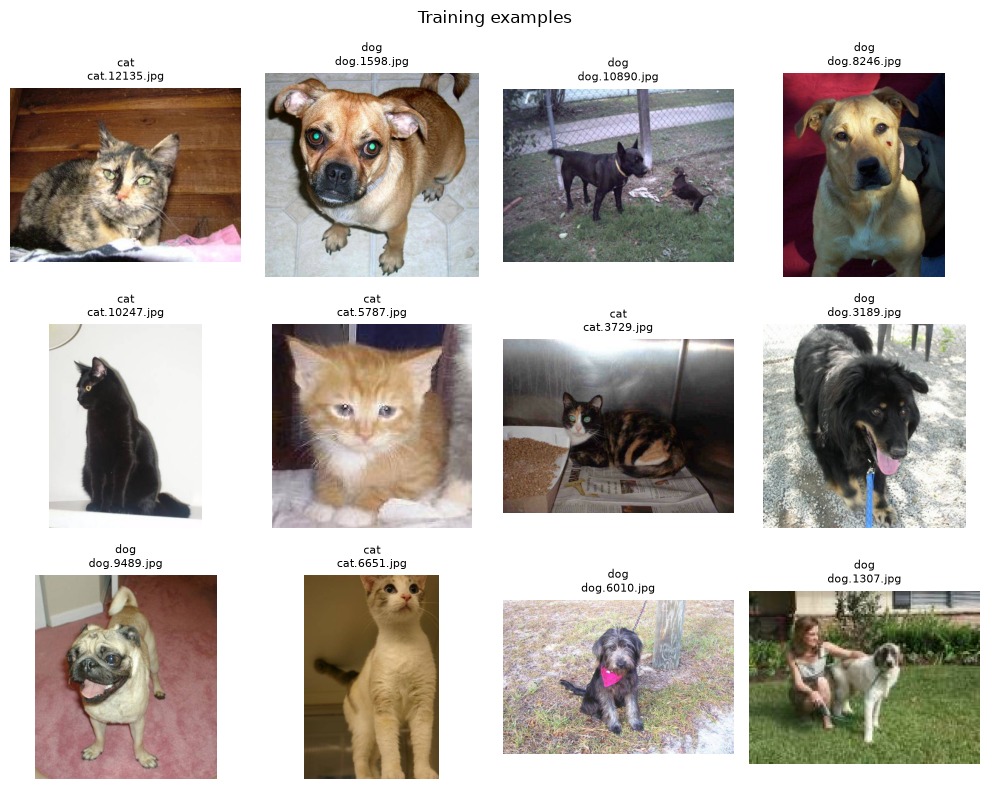

In [5]:
def display_examples(paths, labels, title, output_name, n=12):
    n = min(n, len(paths))
    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for axis in axes.flat:
        axis.axis("off")
    for axis, path, label in zip(axes.flat, paths[:n], labels[:n]):
        with Image.open(path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{'dog' if label else 'cat'}\n{Path(path).name}", fontsize=8)
        axis.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)


display_examples(train_paths, train_labels, "Training examples", "cat_dog_examples.png")


## 3. Build an input pipeline

Decode and resize images lazily so the entire dataset does not need to fit
in memory. Training shuffles; validation and test do not, which keeps
prediction order aligned with their path and label arrays.


In [6]:
def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape((None, None, 3))
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, tf.cast(label, tf.float32)


def make_dataset(paths, labels, training=False):
    path_strings = np.asarray([str(path) for path in paths])
    labels = np.asarray(labels, dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((path_strings, labels))
    if training:
        dataset = dataset.shuffle(
            len(path_strings),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

sample_batch, sample_batch_labels = next(iter(train_ds.take(1)))
assert sample_batch.shape[1:] == (*IMAGE_SIZE, 3)
assert sample_batch.dtype == tf.float32
assert float(tf.reduce_min(sample_batch)) >= 0.0
assert float(tf.reduce_max(sample_batch)) <= 255.0
print(f"Batch shape: {sample_batch.shape}; labels: {sample_batch_labels.shape}")


Batch shape: (32, 128, 128, 3); labels: (32,)


## 4. Build a transfer-learning model

MobileNetV2 was trained on ImageNet. Keep its convolutional base frozen
for the first phase and train a new binary head. Augmentation is inside
the model, so it is active during training and inactive during evaluation.
Batch normalization layers in the frozen base are called with
`training=False`, preserving their learned statistics.


In [7]:
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.08),
        keras.layers.RandomZoom(0.10),
    ],
    name="cat_dog_augmentation",
)

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg",
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = keras.layers.Dropout(0.20, name="classifier_dropout")(x)
outputs = keras.layers.Dense(1, activation="sigmoid", name="dog_probability")(x)
model = keras.Model(inputs, outputs, name="cat_dog_mobilenetv2")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)
model.summary()
print(f"Frozen base parameters: {base_model.count_params():,}")


Model: "cat_dog_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cat_dog_augmentation            │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dog_probability (Dense)         │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Frozen base parameters: 2,257,984


## 5. Train the classifier head

Early stopping monitors validation loss. The test set is still not used.


In [8]:
keras.utils.set_random_seed(RANDOM_STATE)
head_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)


Epoch 1/4


100/100 - 13s - 129ms/step - accuracy: 0.8719 - auc: 0.9457 - loss: 0.3005 - precision: 0.8790 - recall: 0.8625 - val_accuracy: 0.9650 - val_auc: 0.9935 - val_loss: 0.1157 - val_precision: 0.9515 - val_recall: 0.9800


Epoch 2/4


100/100 - 14s - 145ms/step - accuracy: 0.9356 - auc: 0.9849 - loss: 0.1579 - precision: 0.9356 - recall: 0.9356 - val_accuracy: 0.9750 - val_auc: 0.9963 - val_loss: 0.0860 - val_precision: 0.9657 - val_recall: 0.9850


Epoch 3/4


100/100 - 17s - 172ms/step - accuracy: 0.9553 - auc: 0.9917 - loss: 0.1186 - precision: 0.9579 - recall: 0.9525 - val_accuracy: 0.9775 - val_auc: 0.9969 - val_loss: 0.0766 - val_precision: 0.9704 - val_recall: 0.9850


Epoch 4/4


100/100 - 23s - 229ms/step - accuracy: 0.9513 - auc: 0.9901 - loss: 0.1266 - precision: 0.9535 - recall: 0.9488 - val_accuracy: 0.9750 - val_auc: 0.9972 - val_loss: 0.0822 - val_precision: 0.9612 - val_recall: 0.9900


,phase,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,frozen base,1,0.8719,0.9457,0.3005,0.8790,0.8625,0.9650,0.9935,0.1157,0.9515,0.980
1,frozen base,2,0.9356,0.9849,0.1579,0.9356,0.9356,0.9750,0.9963,0.0860,0.9657,0.985
2,frozen base,3,0.9553,0.9917,0.1186,0.9579,0.9525,0.9775,0.9969,0.0766,0.9704,0.985
3,frozen base,4,0.9513,0.9901,0.1266,0.9535,0.9488,0.9750,0.9972,0.0822,0.9612,0.990


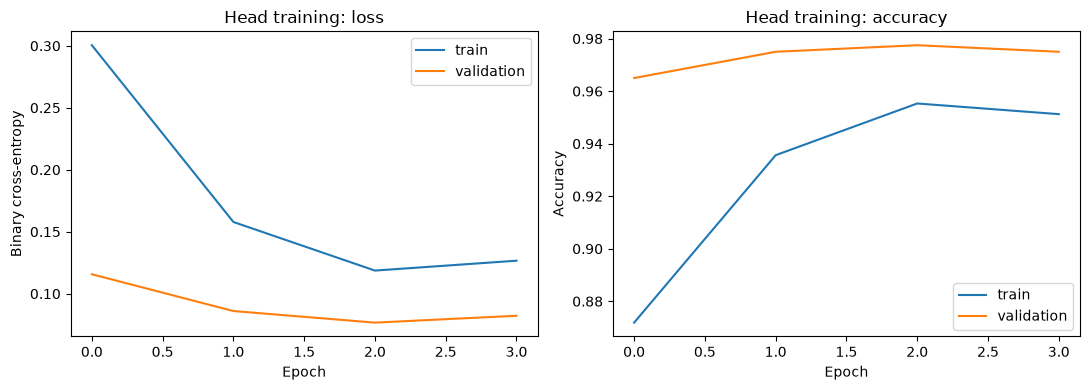

In [9]:
def history_frame(history, phase):
    frame = pd.DataFrame(history.history)
    frame.insert(0, "epoch", np.arange(1, len(frame) + 1))
    frame.insert(0, "phase", phase)
    return frame


head_history_frame = history_frame(head_history, "frozen base")
display(head_history_frame.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(head_history.history["loss"], label="train")
axes[0].plot(head_history.history["val_loss"], label="validation")
axes[0].set(title="Head training: loss", xlabel="Epoch", ylabel="Binary cross-entropy")
axes[0].legend()
axes[1].plot(head_history.history["accuracy"], label="train")
axes[1].plot(head_history.history["val_accuracy"], label="validation")
axes[1].set(title="Head training: accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cat_dog_head_history.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


## 6. Fine-tune the later feature layers

Unfreeze only the last part of the base and use a learning rate two orders
of magnitude smaller than the head-training rate. Batch-normalization
layers remain frozen because updating their statistics on a small dataset
can destabilize transfer learning.


In [10]:
base_model.trainable = True
fine_tune_start = max(0, len(base_model.layers) - 30)
for layer in base_model.layers[:fine_tune_start]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable_base = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Trainable base layers ({len(trainable_base)}): {trainable_base[:5]} ...")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)
fine_tune_history_frame = history_frame(fine_tune_history, "fine-tuned")
display(fine_tune_history_frame.round(4))


Trainable base layers (20): ['block_14_expand', 'block_14_expand_relu', 'block_14_depthwise', 'block_14_depthwise_relu', 'block_14_project'] ...
Epoch 1/2


100/100 - 54s - 545ms/step - accuracy: 0.9541 - auc: 0.9906 - loss: 0.1229 - precision: 0.9561 - recall: 0.9519 - val_accuracy: 0.9775 - val_auc: 0.9975 - val_loss: 0.0690 - val_precision: 0.9704 - val_recall: 0.9850


Epoch 2/2


100/100 - 32s - 321ms/step - accuracy: 0.9681 - auc: 0.9944 - loss: 0.0922 - precision: 0.9687 - recall: 0.9675 - val_accuracy: 0.9800 - val_auc: 0.9975 - val_loss: 0.0628 - val_precision: 0.9752 - val_recall: 0.9850


,phase,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,fine-tuned,1,0.9541,0.9906,0.1229,0.9561,0.9519,0.9775,0.9975,0.0690,0.9704,0.985
1,fine-tuned,2,0.9681,0.9944,0.0922,0.9687,0.9675,0.9800,0.9975,0.0628,0.9752,0.985


,phase,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,frozen base,1,0.8719,0.9457,0.3005,0.8790,0.8625,0.9650,0.9935,0.1157,0.9515,0.980
1,frozen base,2,0.9356,0.9849,0.1579,0.9356,0.9356,0.9750,0.9963,0.0860,0.9657,0.985
2,frozen base,3,0.9553,0.9917,0.1186,0.9579,0.9525,0.9775,0.9969,0.0766,0.9704,0.985
3,frozen base,4,0.9513,0.9901,0.1266,0.9535,0.9488,0.9750,0.9972,0.0822,0.9612,0.990
4,fine-tuned,5,0.9541,0.9906,0.1229,0.9561,0.9519,0.9775,0.9975,0.0690,0.9704,0.985
5,fine-tuned,6,0.9681,0.9944,0.0922,0.9687,0.9675,0.9800,0.9975,0.0628,0.9752,0.985


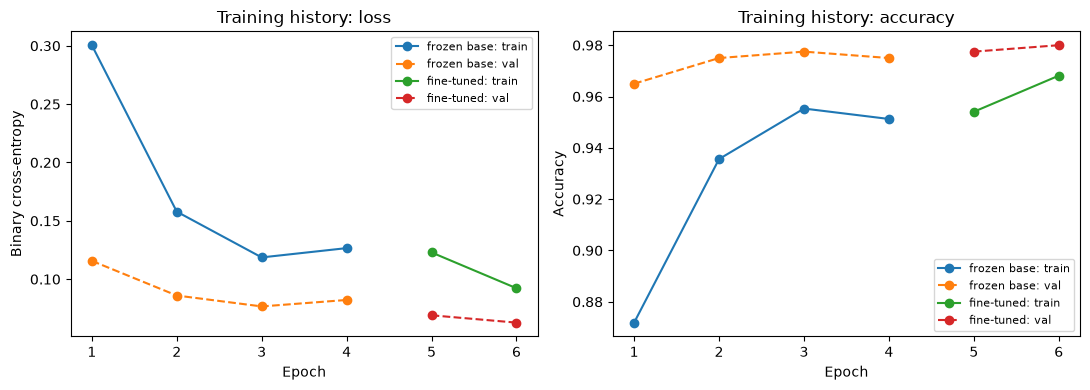

In [11]:
def combine_history_frames(*frames):
    offset = 0
    adjusted = []
    for frame in frames:
        frame = frame.copy()
        frame["epoch"] = frame["epoch"] + offset
        adjusted.append(frame)
        offset = int(frame["epoch"].max())
    return pd.concat(adjusted, ignore_index=True)


training_history = combine_history_frames(
    head_history_frame,
    fine_tune_history_frame,
)
display(training_history.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for phase, frame in training_history.groupby("phase", sort=False):
    axes[0].plot(frame["epoch"], frame["loss"], marker="o", label=f"{phase}: train")
    axes[0].plot(
        frame["epoch"], frame["val_loss"], marker="o", linestyle="--", label=f"{phase}: val"
    )
    axes[1].plot(frame["epoch"], frame["accuracy"], marker="o", label=f"{phase}: train")
    axes[1].plot(
        frame["epoch"],
        frame["val_accuracy"],
        marker="o",
        linestyle="--",
        label=f"{phase}: val",
    )
axes[0].set(title="Training history: loss", xlabel="Epoch", ylabel="Binary cross-entropy")
axes[1].set(title="Training history: accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cat_dog_training_history.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


## 7. Evaluate with a validation-selected threshold

A default threshold of 0.5 is not automatically appropriate when the
product requirement is high precision. Select a threshold on validation
predictions, then freeze it before evaluating the test set.


In [12]:
def predict_probabilities(model, dataset, expected_count):
    probabilities = model.predict(dataset, verbose=0).reshape(-1)
    if len(probabilities) != expected_count:
        raise ValueError(
            f"Expected {expected_count} predictions, got {len(probabilities)}"
        )
    if not np.isfinite(probabilities).all() or not ((0 <= probabilities).all() and (probabilities <= 1).all()):
        raise ValueError("Predicted probabilities must be finite values in [0, 1]")
    return probabilities


def threshold_table(labels, probabilities, thresholds):
    rows = []
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(np.int32)
        rows.append(
            {
                "threshold": threshold,
                "precision": precision_score(labels, predictions, zero_division=0),
                "recall": recall_score(labels, predictions, zero_division=0),
                "f1": f1_score(labels, predictions, zero_division=0),
                "accuracy": accuracy_score(labels, predictions),
            }
        )
    return pd.DataFrame(rows)


val_probabilities = predict_probabilities(model, val_ds, len(val_paths))
test_probabilities = predict_probabilities(model, test_ds, len(test_paths))
thresholds = np.linspace(0.05, 0.95, 19)
validation_thresholds = threshold_table(val_labels, val_probabilities, thresholds)
display(validation_thresholds.round(4))

eligible = validation_thresholds[
    validation_thresholds["precision"] >= TARGET_PRECISION
]
if len(eligible):
    selected_threshold = float(
        eligible.sort_values(
            ["recall", "threshold"], ascending=[False, True]
        ).iloc[0]["threshold"]
    )
else:
    selected_threshold = 0.50
    print(
        f"No validation threshold reached precision {TARGET_PRECISION:.0%}; "
        "using 0.50."
    )
print(f"Selected threshold: {selected_threshold:.2f}")


,threshold,precision,recall,f1,accuracy
0,0.05,0.9213,0.995,0.9567,0.9550
1,0.10,0.9340,0.990,0.9612,0.9600
2,0.15,0.9519,0.990,0.9706,0.9700
3,0.20,0.9706,0.990,0.9802,0.9800
4,0.25,0.9706,0.990,0.9802,0.9800
5,0.30,0.9706,0.990,0.9802,0.9800
6,0.35,0.9704,0.985,0.9777,0.9775
7,0.40,0.9704,0.985,0.9777,0.9775
8,0.45,0.9704,0.985,0.9777,0.9775
9,0.50,0.9752,0.985,0.9801,0.9800


Selected threshold: 0.05


In [13]:
def evaluate_binary_predictions(labels, probabilities, threshold, split_name):
    predictions = (probabilities >= threshold).astype(np.int32)
    metrics = {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(labels, predictions),
        "precision_dog": precision_score(labels, predictions, zero_division=0),
        "recall_dog": recall_score(labels, predictions, zero_division=0),
        "f1_dog": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
    }
    print(pd.Series(metrics).to_string())
    report = classification_report(
        labels,
        predictions,
        target_names=["cat", "dog"],
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report).T.round(4))
    return predictions, metrics


val_predictions, val_metrics = evaluate_binary_predictions(
    val_labels,
    val_probabilities,
    selected_threshold,
    "validation",
)
test_predictions, test_metrics = evaluate_binary_predictions(
    test_labels,
    test_probabilities,
    selected_threshold,
    "test",
)
assert 0.0 <= test_metrics["precision_dog"] <= 1.0
assert 0.0 <= test_metrics["recall_dog"] <= 1.0


split            validation
threshold              0.05
accuracy              0.955
precision_dog      0.921296
recall_dog            0.995
f1_dog             0.956731
roc_auc             0.99755


,precision,recall,f1-score,support
cat,0.9946,0.915,0.9531,200.000
dog,0.9213,0.995,0.9567,200.000
accuracy,0.9550,0.955,0.9550,0.955
macro avg,0.9579,0.955,0.9549,400.000
weighted avg,0.9579,0.955,0.9549,400.000


split                test
threshold            0.05
accuracy           0.9625
precision_dog    0.934272
recall_dog          0.995
f1_dog            0.96368
roc_auc           0.99685


,precision,recall,f1-score,support
cat,0.9947,0.9300,0.9612,200.0000
dog,0.9343,0.9950,0.9637,200.0000
accuracy,0.9625,0.9625,0.9625,0.9625
macro avg,0.9645,0.9625,0.9625,400.0000
weighted avg,0.9645,0.9625,0.9625,400.0000


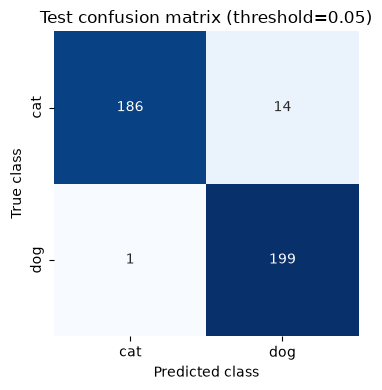

Dog precision target (90%) is met: 0.934


In [14]:
test_confusion = confusion_matrix(test_labels, test_predictions, labels=[0, 1])
fig, axis = plt.subplots(figsize=(5, 4))
import seaborn as sns

sns.heatmap(
    test_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=["cat", "dog"],
    yticklabels=["cat", "dog"],
    ax=axis,
)
axis.set(
    title=f"Test confusion matrix (threshold={selected_threshold:.2f})",
    xlabel="Predicted class",
    ylabel="True class",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cat_dog_confusion_matrix.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

target_status = "met" if test_metrics["precision_dog"] >= TARGET_PRECISION else "not met"
print(
    f"Dog precision target ({TARGET_PRECISION:.0%}) is {target_status}: "
    f"{test_metrics['precision_dog']:.3f}"
)


**Interpretation.** Precision answers: “Of the images predicted as dogs,
how many were dogs?” Recall answers: “Of all dogs, how many did the model
find?” Raising the threshold generally trades recall for precision. The
selected threshold is valid only for data with similar preprocessing and
class definitions; it must be revalidated after a data or product change.


## 8. Inspect predictions and errors


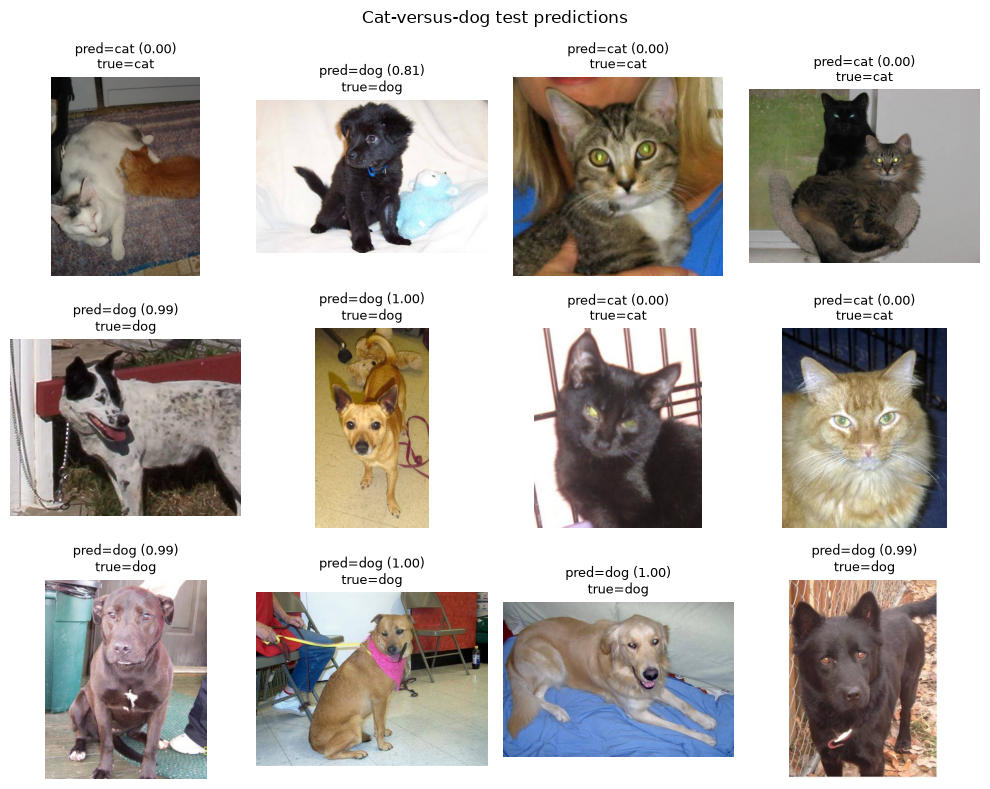

Test errors: 15 / 400


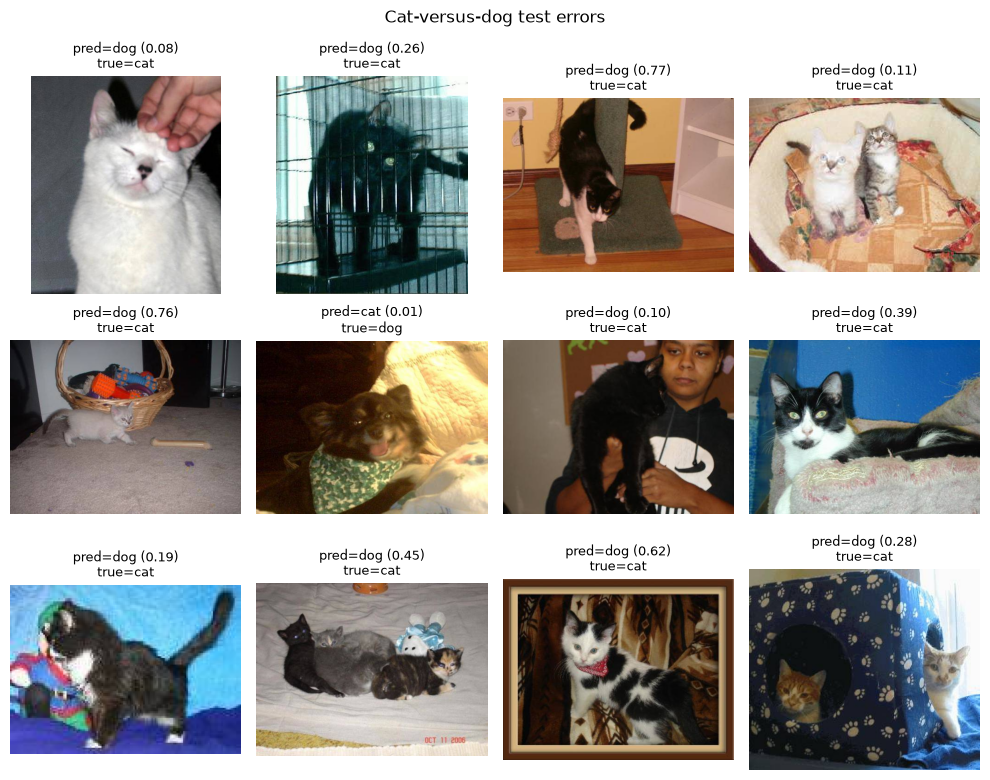

In [15]:
def display_predictions(paths, labels, probabilities, predictions, title, output_name, n=12):
    n = min(n, len(paths))
    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for axis in axes.flat:
        axis.axis("off")
    for axis, path, label, probability, prediction in zip(
        axes.flat,
        paths[:n],
        labels[:n],
        probabilities[:n],
        predictions[:n],
    ):
        with Image.open(path) as image:
            axis.imshow(image.convert("RGB"))
        actual = "dog" if label else "cat"
        predicted = "dog" if prediction else "cat"
        axis.set_title(
            f"pred={predicted} ({probability:.2f})\ntrue={actual}",
            fontsize=9,
        )
        axis.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)


display_predictions(
    test_paths,
    test_labels,
    test_probabilities,
    test_predictions,
    "Cat-versus-dog test predictions",
    "cat_dog_predictions.png",
)

error_indices = np.flatnonzero(test_predictions != test_labels)
print(f"Test errors: {len(error_indices):,} / {len(test_labels):,}")
if len(error_indices):
    display_predictions(
        test_paths[error_indices],
        test_labels[error_indices],
        test_probabilities[error_indices],
        test_predictions[error_indices],
        "Cat-versus-dog test errors",
        "cat_dog_errors.png",
    )


## 9. Save the reproducible artifact

Save the model in the native Keras format. The threshold is saved beside
it because the model probability and the application decision threshold
are separate artifacts.


In [16]:
model_path = OUTPUT_DIR / "cat_dog_mobilenetv2.keras"
model.save(model_path)
pd.DataFrame([test_metrics]).to_csv(OUTPUT_DIR / "cat_dog_test_metrics.csv", index=False)
pd.DataFrame(
    [{"target_precision": TARGET_PRECISION, "selected_threshold": selected_threshold}]
).to_json(OUTPUT_DIR / "cat_dog_threshold.json", orient="records", indent=2)
print(f"Saved model: {model_path}")


Saved model: outputs/cat_dog_mobilenetv2.keras


## Conclusion

Report the dataset size and split, the model architecture, the effect of
frozen-base training versus fine-tuning, and test accuracy/precision/
recall/F1 at the validation-selected threshold. Discuss false positives
and false negatives using the displayed examples. A high score on this
dataset does not guarantee reliable predictions for selfies or other
images outside the training distribution.
